In [8]:
import requests
import json

API_KEY = "SWwLvpvu_Ob4Mn6EBzlmf9_32yAYnSII"

url = "https://api.massive.com/v3/reference/tickers"

params = {
    "apiKey": API_KEY,
    "market": "fx",
    "active": "true",
    "limit": 5
}

response = requests.get(
    url,
    params=params
)

data = response.json()

print(json.dumps(
    data,
    indent=4
))

{
    "results": [
        {
            "ticker": "C:AEDAUD",
            "name": "United Arab Emirates dirham - Australian dollar",
            "market": "fx",
            "locale": "global",
            "active": true,
            "currency_symbol": "AUD",
            "currency_name": "Australian dollar",
            "base_currency_symbol": "AED",
            "base_currency_name": "United Arab Emirates dirham",
            "last_updated_utc": "2017-01-01T00:00:00Z"
        },
        {
            "ticker": "C:AEDBHD",
            "name": "United Arab Emirates dirham - Bahraini dinar",
            "market": "fx",
            "locale": "global",
            "active": true,
            "currency_symbol": "BHD",
            "currency_name": "Bahraini dinar",
            "base_currency_symbol": "AED",
            "base_currency_name": "United Arab Emirates dirham",
            "last_updated_utc": "2017-01-01T00:00:00Z"
        },
        {
            "ticker": "C:AEDCAD",
            "

In [13]:
import requests
import json


API_KEY = "SWwLvpvu_Ob4Mn6EBzlmf9_32yAYnSII"

ticker = "C:EURUSD"

url = (
    f"https://api.massive.com/v2/aggs/ticker/"
    f"{ticker}/range/1/minute/"
    f"2026-07-17/"
    f"2026-07-18"
)

params = {
    "apiKey": API_KEY
}


response = requests.get(
    url,
    params=params
)


print("STATUS:", response.status_code)

data = response.json()

print(json.dumps(data, indent=4)[:2000])

STATUS: 200
{
    "ticker": "C:EURUSD",
    "queryCount": 1260,
    "resultsCount": 1260,
    "adjusted": true,
    "results": [
        {
            "v": 206,
            "vw": 1.1445,
            "o": 1.14449,
            "c": 1.14449,
            "h": 1.14454,
            "l": 1.1443,
            "t": 1784246400000,
            "n": 206
        },
        {
            "v": 166,
            "vw": 1.1445,
            "o": 1.14453,
            "c": 1.1445,
            "h": 1.14454,
            "l": 1.1443,
            "t": 1784246460000,
            "n": 166
        },
        {
            "v": 158,
            "vw": 1.1445,
            "o": 1.1445,
            "c": 1.1445,
            "h": 1.14456,
            "l": 1.1443,
            "t": 1784246520000,
            "n": 158
        },
        {
            "v": 157,
            "vw": 1.1446,
            "o": 1.14452,
            "c": 1.1446,
            "h": 1.14462,
            "l": 1.1443,
            "t": 1784246580000,
       

In [15]:
import pandas as pd


# Extract candle results
df = pd.DataFrame(data["results"])


# Rename Massive fields to standard OHLCV
df = df.rename(
    columns={
        "t": "timestamp",
        "o": "open",
        "h": "high",
        "l": "low",
        "c": "close",
        "v": "volume"
    }
)


# Convert timestamp milliseconds -> datetime UTC
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    unit="ms",
    utc=True
)


# Convert to Philippines timezone
df["timestamp_ph"] = (
    df["timestamp"]
    .dt.tz_convert("Asia/Manila")
)


# Reorder columns
df = df[
    [
        "timestamp",
        "timestamp_ph",
        "open",
        "high",
        "low",
        "close",
        "volume"
    ]
]


df

,timestamp,timestamp_ph,open,high,low,close,volume
0,2026-07-17 00:00:00+00:00,2026-07-17 08:00:00+08:00,1.14449,1.14454,1.14430,1.14449,206
1,2026-07-17 00:01:00+00:00,2026-07-17 08:01:00+08:00,1.14453,1.14454,1.14430,1.14450,166
2,2026-07-17 00:02:00+00:00,2026-07-17 08:02:00+08:00,1.14450,1.14456,1.14430,1.14450,158
3,2026-07-17 00:03:00+00:00,2026-07-17 08:03:00+08:00,1.14452,1.14462,1.14430,1.14460,157
4,2026-07-17 00:04:00+00:00,2026-07-17 08:04:00+08:00,1.14460,1.14461,1.14430,1.14452,154
...,...,...,...,...,...,...,...
1255,2026-07-17 20:55:00+00:00,2026-07-18 04:55:00+08:00,1.14370,1.14380,1.14360,1.14366,63
1256,2026-07-17 20:56:00+00:00,2026-07-18 04:56:00+08:00,1.14372,1.14390,1.14358,1.14375,40
1257,2026-07-17 20:57:00+00:00,2026-07-18 04:57:00+08:00,1.14377,1.14390,1.14360,1.14370,47
1258,2026-07-17 20:58:00+00:00,2026-07-18 04:58:00+08:00,1.14360,1.14380,1.14359,1.14361,46


In [16]:
df.loc[
    df["timestamp_ph"] == pd.Timestamp("2026-07-18 23:55:00", tz="Asia/Manila")
]

,timestamp,timestamp_ph,open,high,low,close,volume


In [17]:
df["timestamp_ph"].min(), df["timestamp_ph"].max()

(Timestamp('2026-07-17 08:00:00+0800', tz='Asia/Manila'),
 Timestamp('2026-07-18 04:59:00+0800', tz='Asia/Manila'))

In [18]:
df.loc[
    df["timestamp_ph"] == pd.Timestamp("2026-07-18 04:59:00", tz="Asia/Manila")
]

,timestamp,timestamp_ph,open,high,low,close,volume
1259,2026-07-17 20:59:00+00:00,2026-07-18 04:59:00+08:00,1.14362,1.1439,1.1436,1.14366,32


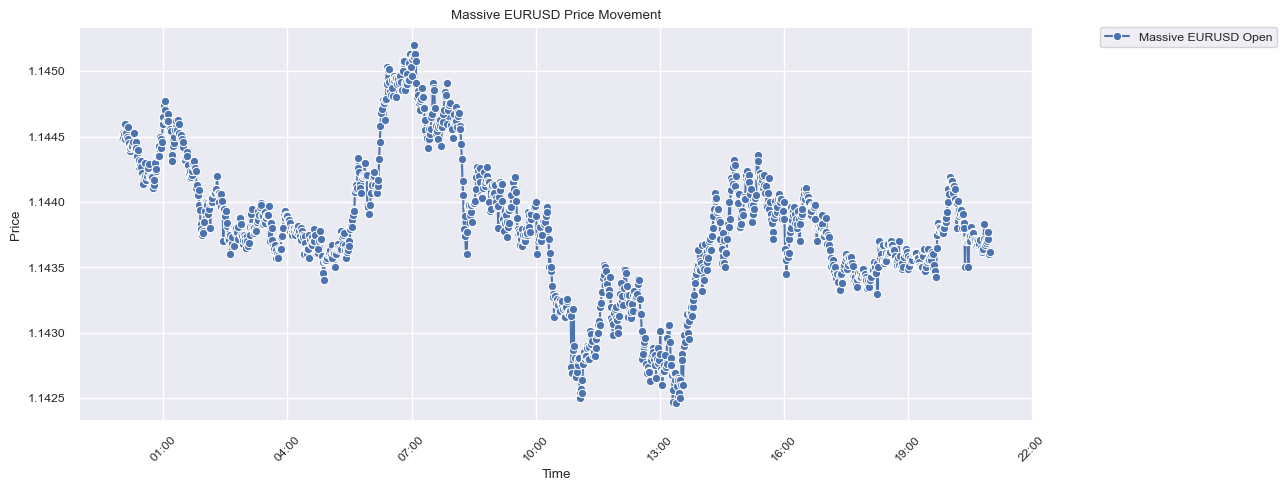

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


sns.set_theme(font_scale=0.8)

fig, ax1 = plt.subplots(figsize=(13, 5))


sns.lineplot(
    data=df,
    x="timestamp_ph",
    y="open",
    ax=ax1,
    label="Massive EURUSD Open",
    marker="o"
)


ax1.set_title("Massive EURUSD Price Movement")
ax1.set_xlabel("Time")
ax1.set_ylabel("Price")


# Format datetime axis
ax1.xaxis.set_major_formatter(
    mdates.DateFormatter("%H:%M")
)

plt.xticks(rotation=45)


ax1.legend(
    loc="upper left",
    bbox_to_anchor=(1.07, 1.0),
    borderaxespad=0
)


plt.tight_layout()
plt.show()

,timestamp,timestamp_ph,open,high,low,close,volume
1230,2026-07-17 20:30:00+00:00,2026-07-18 04:30:00+08:00,1.14374,1.14383,1.14360,1.14379,57
1231,2026-07-17 20:31:00+00:00,2026-07-18 04:31:00+08:00,1.14370,1.14382,1.14360,1.14378,60
1232,2026-07-17 20:32:00+00:00,2026-07-18 04:32:00+08:00,1.14381,1.14381,1.14360,1.14377,73
1233,2026-07-17 20:33:00+00:00,2026-07-18 04:33:00+08:00,1.14374,1.14380,1.14360,1.14380,50
1234,2026-07-17 20:34:00+00:00,2026-07-18 04:34:00+08:00,1.14377,1.14390,1.14360,1.14378,46
1235,2026-07-17 20:35:00+00:00,2026-07-18 04:35:00+08:00,1.14376,1.14380,1.14360,1.14370,32
1236,2026-07-17 20:36:00+00:00,2026-07-18 04:36:00+08:00,1.14372,1.14376,1.14360,1.14373,42
1237,2026-07-17 20:37:00+00:00,2026-07-18 04:37:00+08:00,1.14371,1.14373,1.14350,1.14369,38
1238,2026-07-17 20:38:00+00:00,2026-07-18 04:38:00+08:00,1.14368,1.14373,1.14350,1.14370,24
1239,2026-07-17 20:39:00+00:00,2026-07-18 04:39:00+08:00,1.14367,1.14380,1.14360,1.14370,37


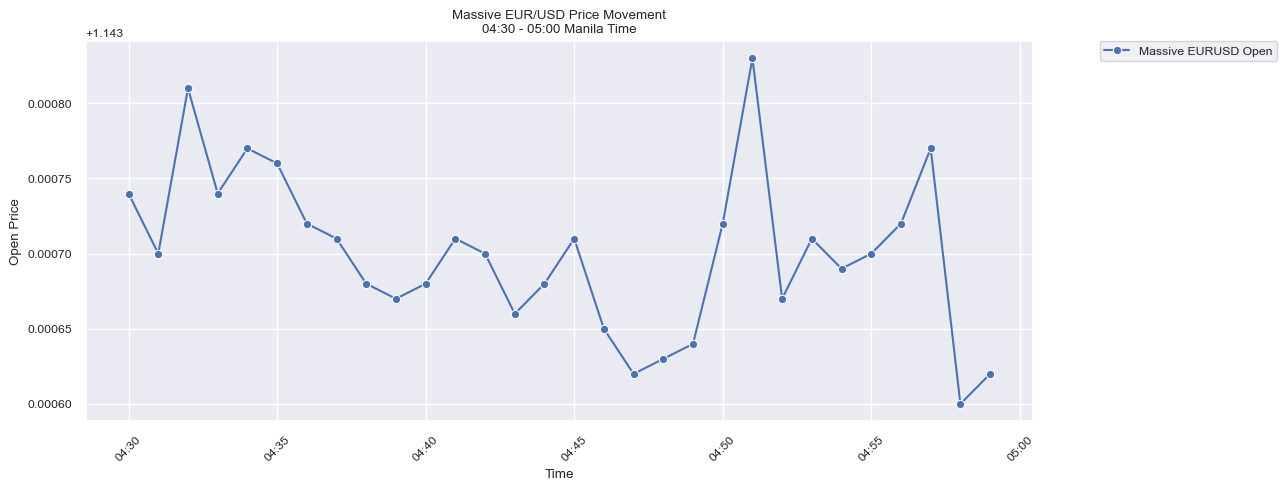

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd


# ============================================
# FILTER MASSIVE DATA
# 04:30:00 - 05:00:00 Manila Time
# ============================================

start_time = pd.Timestamp(
    "2026-07-18 04:30:00",
    tz="Asia/Manila"
)

end_time = pd.Timestamp(
    "2026-07-18 05:00:00",
    tz="Asia/Manila"
)


segment = df[
    (df["timestamp_ph"] >= start_time) &
    (df["timestamp_ph"] <= end_time)
].copy()


# Check data
display(segment)


# ============================================
# VISUALIZE OPEN PRICE MOVEMENT
# ============================================

sns.set_theme(font_scale=0.8)

fig, ax = plt.subplots(
    figsize=(13,5)
)


sns.lineplot(
    data=segment,
    x="timestamp_ph",
    y="open",
    ax=ax,
    label="Massive EURUSD Open",
    marker="o"
)


ax.set_title(
    "Massive EUR/USD Price Movement\n04:30 - 05:00 Manila Time"
)

ax.set_xlabel("Time")
ax.set_ylabel("Open Price")


from zoneinfo import ZoneInfo

ax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%H:%M",
        tz=ZoneInfo("Asia/Manila")
    )
)

plt.xticks(rotation=45)


ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.07, 1.0),
    borderaxespad=0
)


plt.tight_layout()
plt.show()

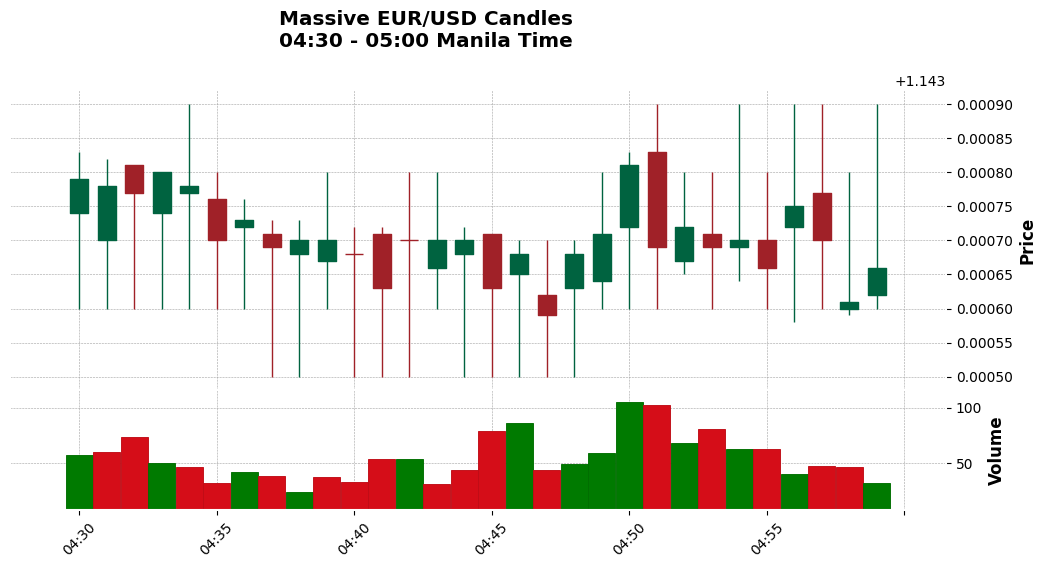

In [25]:
import mplfinance as mpf
import pandas as pd


# ============================================
# FILTER TIME WINDOW
# 04:30 - 05:00 Manila Time
# ============================================

start_time = pd.Timestamp(
    "2026-07-18 04:30:00",
    tz="Asia/Manila"
)

end_time = pd.Timestamp(
    "2026-07-18 05:00:00",
    tz="Asia/Manila"
)


segment = df[
    (df["timestamp_ph"] >= start_time) &
    (df["timestamp_ph"] <= end_time)
].copy()


# ============================================
# PREPARE DATA FOR MPLFINANCE
# ============================================

candle_df = segment[
    [
        "timestamp_ph",
        "open",
        "high",
        "low",
        "close",
        "volume"
    ]
].copy()


# mplfinance requires datetime index
candle_df = candle_df.set_index(
    "timestamp_ph"
)


# ============================================
# PLOT CANDLESTICK CHART
# ============================================

mpf.plot(
    candle_df,
    type="candle",
    style="charles",
    title="Massive EUR/USD Candles\n04:30 - 05:00 Manila Time",
    ylabel="Price",
    volume=True,
    figsize=(13,6),
    datetime_format="%H:%M"
)

In [24]:
!pip install mplfinance